In [1]:
%load_ext autoreload
%autoreload 2
%reset -f

In [2]:
from locallib.picarrodb import *
from locallib.query import *
import pandas as pd

EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully
EU1_PROD_Conn created successfully
EU2_PROD_Conn created successfully


In [3]:
a = get_users(customer_name = 'ENBW', user_table = '#TempUser')
b = get_surveys(user_table = '#TempUser', survey_table = '#TempSurvey', start_date = '2025-01-01')
b.set_child(Query(
    query = (
        "SELECT "
        "COUNT(P.Id) AS PeakCount, "
        "P.SurveyId, "
        "SQA.AverageFlowRate "
        "INTO #TempPeak "
        "FROM Peak P "
        "LEFT JOIN SurveyQACheck SQA ON P.SurveyId = SQA.SurveyId "
        "WHERE P.SurveyId IN (SELECT SurveyId FROM #TempSurvey) "
   
        "GROUP BY P.SurveyId, SQA.AverageFlowRate"
    )
))
a.set_child(b)
data = a.execute(EU1_Conn, table_return = ['#TempPeak', '#TempSurvey'])

In [4]:
peak_survey = pd.merge(data['#TempSurvey'][['SurveyId', 'SurveyorUnit','RawDurationMinutes','StartDateTime','EndDateTime']], data['#TempPeak'][['PeakCount', 'SurveyId', 'AverageFlowRate']], on = 'SurveyId', how = 'left')
peak_survey['AverageFlowRate'] = peak_survey['AverageFlowRate'].astype(float)
peak_survey = peak_survey.dropna(subset=['AverageFlowRate'])

In [5]:
peak_survey['PeakMinutes'] = peak_survey['PeakCount'] / peak_survey['RawDurationMinutes']

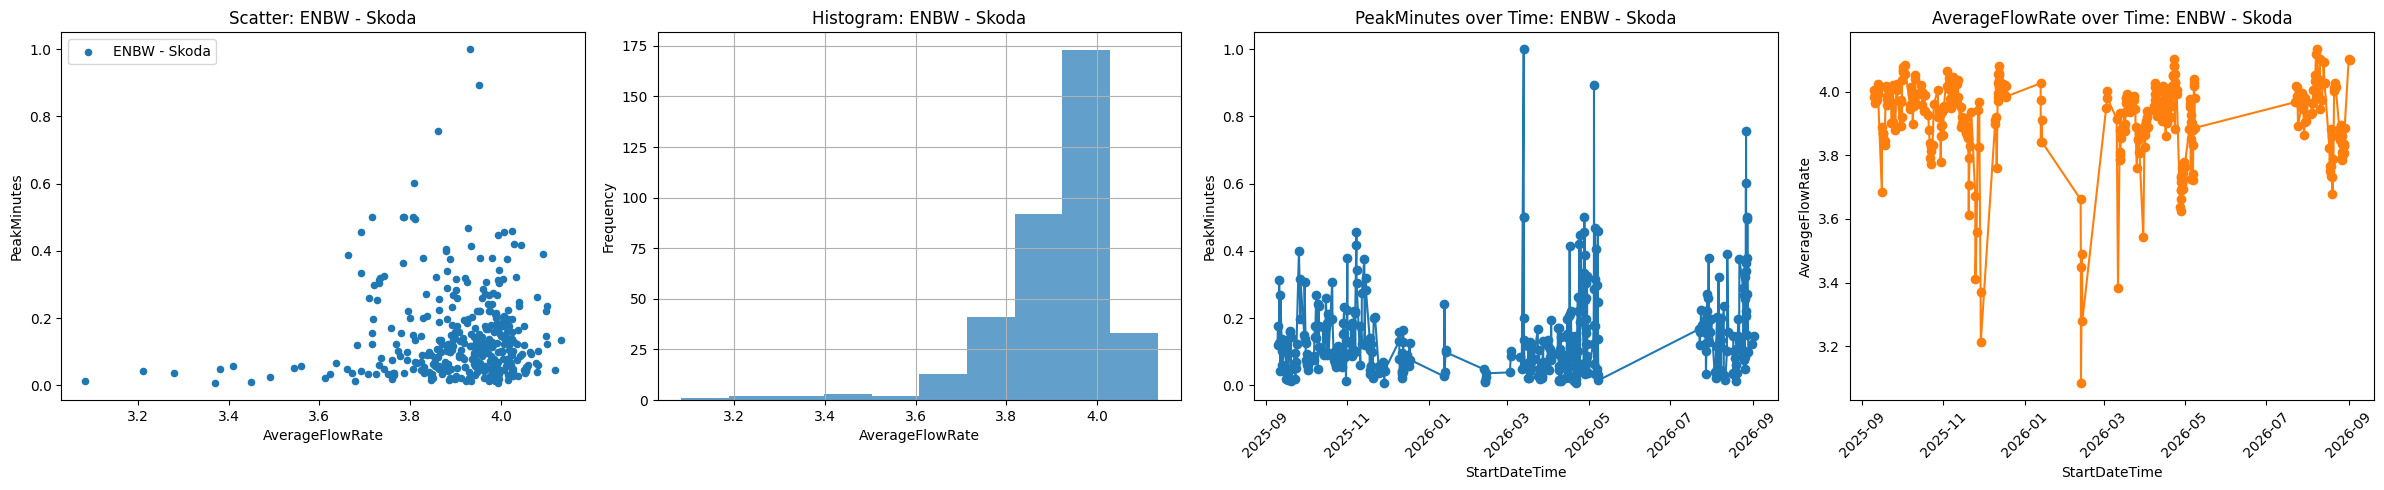

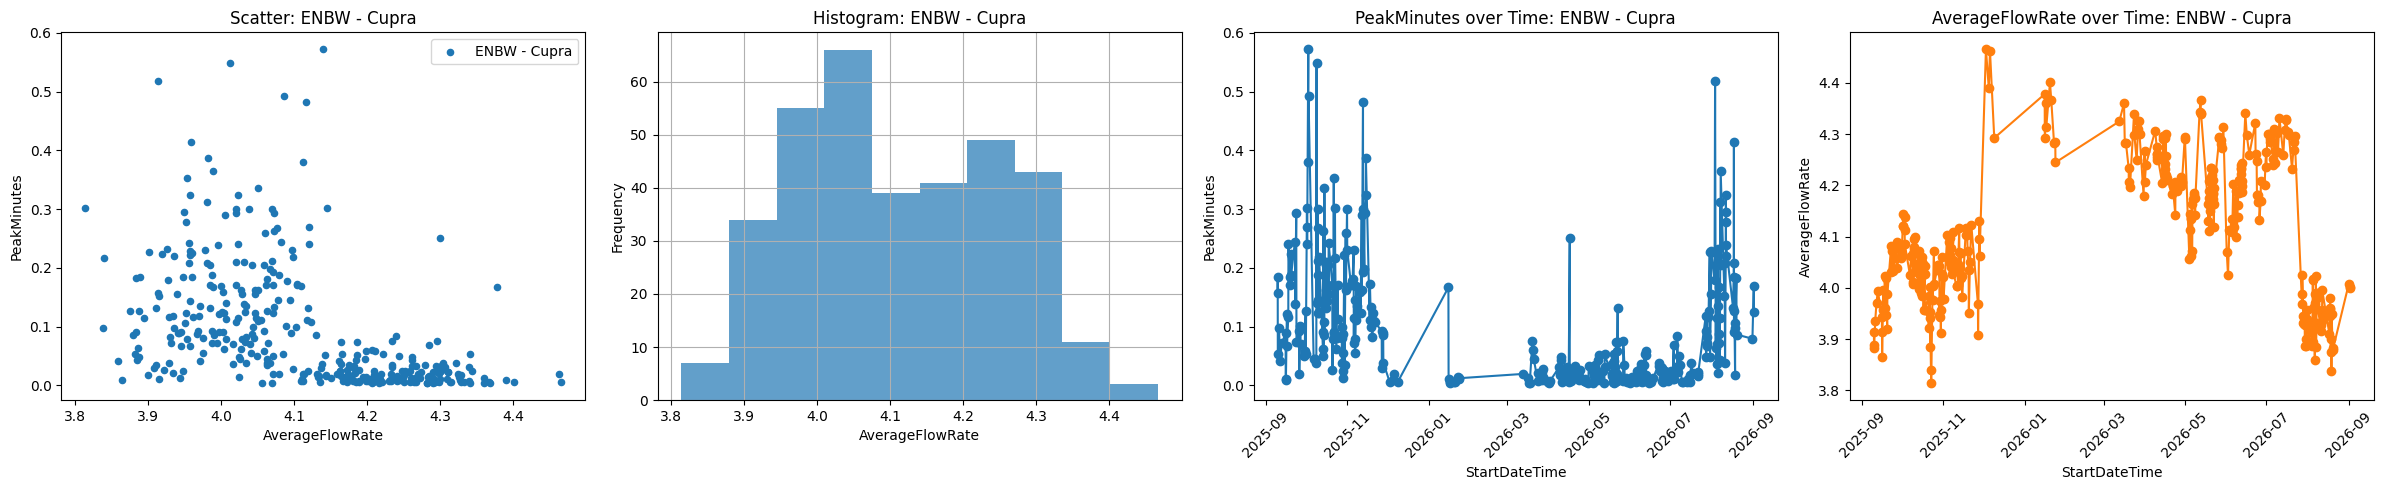

In [6]:
import matplotlib.pyplot as plt

for surveyor_unit in peak_survey['SurveyorUnit'].unique():
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit].sort_values('StartDateTime')

    fig, axs = plt.subplots(1, 4, figsize=(24, 5))

    # 1. Scatter: AverageFlowRate vs PeakMinutes
    subset.plot.scatter(
        x='AverageFlowRate', y='PeakMinutes',
        ax=axs[0], label=surveyor_unit,
        title=f"Scatter: {surveyor_unit}")
    axs[0].set_xlabel('AverageFlowRate')
    axs[0].set_ylabel('PeakMinutes')

    # 2. Histogram of AverageFlowRate
    subset['AverageFlowRate'].hist(ax=axs[1], label=surveyor_unit, alpha=0.7)
    axs[1].set_title(f"Histogram: {surveyor_unit}")
    axs[1].set_xlabel('AverageFlowRate')
    axs[1].set_ylabel('Frequency')

    # 3. Time series: PeakMinutes over time
    axs[2].plot(subset['StartDateTime'], subset['PeakMinutes'], marker='o')
    axs[2].set_xlabel('StartDateTime')
    axs[2].set_ylabel('PeakMinutes')
    axs[2].set_title(f"PeakMinutes over Time: {surveyor_unit}")
    axs[2].tick_params(axis='x', rotation=45)

    # 4. Time series: AverageFlowRate over time
    axs[3].plot(subset['StartDateTime'], subset['AverageFlowRate'], marker='o', color='tab:orange')
    axs[3].set_xlabel('StartDateTime')
    axs[3].set_ylabel('AverageFlowRate')
    axs[3].set_title(f"AverageFlowRate over Time: {surveyor_unit}")
    axs[3].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

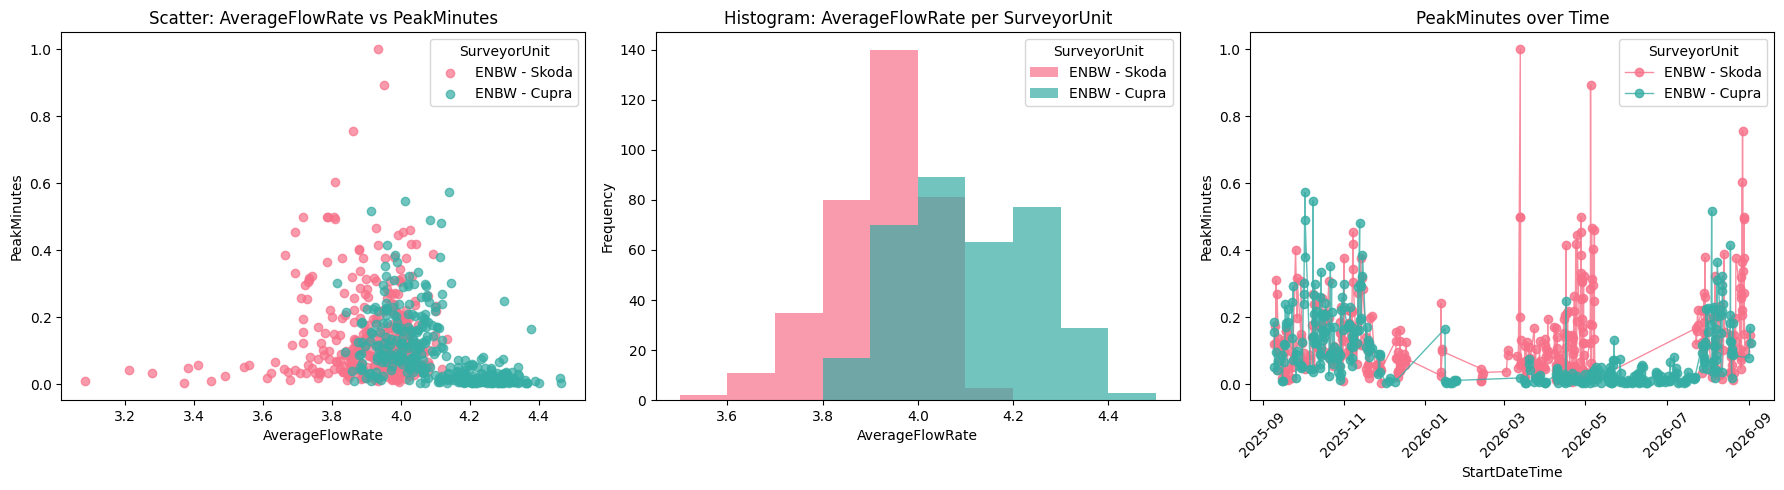

In [7]:
import matplotlib.pyplot as plt

# Assign a color to each unique SurveyorUnit
import seaborn as sns
color_palette = sns.color_palette("husl", len(peak_survey['SurveyorUnit'].unique()))
surveyor_units = peak_survey['SurveyorUnit'].unique()
color_map = dict(zip(surveyor_units, color_palette))

import numpy as np

# Create three plots: scatter, histogram, and time series
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter: AverageFlowRate vs PeakMinutes for all SurveyorUnits
for surveyor_unit in surveyor_units:
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit]
    ax1.scatter(
        subset['AverageFlowRate'],
        subset['PeakMinutes'],
        color=color_map[surveyor_unit],
        label=surveyor_unit,
        alpha=0.7
    )
ax1.set_xlabel('AverageFlowRate')
ax1.set_ylabel('PeakMinutes')
ax1.set_title('Scatter: AverageFlowRate vs PeakMinutes')
ax1.legend(title='SurveyorUnit')

# 2. Overlaid histogram for AverageFlowRate for all SurveyorUnits
bins = np.arange(3.5, 4.5 + 0.01, 0.1)  # step size of 0.1 (adjust as needed)
for surveyor_unit in surveyor_units:
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit]
    ax2.hist(
        subset['AverageFlowRate'].astype(float),
        bins=bins,
        alpha=0.7,
        label=surveyor_unit,
        color=color_map[surveyor_unit]
    )
ax2.set_title("Histogram: AverageFlowRate per SurveyorUnit")
ax2.set_xlabel('AverageFlowRate')
ax2.set_ylabel('Frequency')
ax2.legend(title='SurveyorUnit')

# 3. Time plot: PeakMinutes over StartDateTime for all SurveyorUnits
for surveyor_unit in surveyor_units:
    subset = peak_survey[peak_survey['SurveyorUnit'] == surveyor_unit].sort_values('StartDateTime')
    ax3.plot(
        subset['StartDateTime'],
        subset['PeakMinutes'],
        marker='o',
        label=surveyor_unit,
        color=color_map[surveyor_unit],
        alpha=0.8,
        linewidth=1
    )
ax3.set_xlabel('StartDateTime')
ax3.set_ylabel('PeakMinutes')
ax3.set_title('PeakMinutes over Time')
ax3.legend(title='SurveyorUnit')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [37]:
cupra = peak_survey[peak_survey['SurveyorUnit'] == 'ENBW - Cupra']
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# For rolling mean, sort by StartDateTime
cupra = cupra.sort_values('StartDateTime').reset_index(drop=True)
x = cupra.iloc[:7]
def linear_model(t, a, b):
    return a * t + b

# Convert StartDateTime to numeric (e.g., matplotlib date numbers)
import matplotlib.dates as mdates

# If x is empty, skip the fit
def fit_linear_and_variance(x,column_name = 'AverageFlowRate'):
    """
    Fit a linear model to PeakMinutes in x and return a_fit, b_fit, and the sample variance.
    Also plots the fit and prints fit results.
    """
    if len(x) > 1:
        y = x[column_name].astype(float).values
        n = np.arange(len(x))

        # Fit the linear model
        popt, pcov = curve_fit(linear_model, n, y)
        a_fit, b_fit = popt

        # Calculate the sample variance of y (PeakMinutes)
        sample_variance = np.var(y, ddof=1)  # ddof=1 gives sample variance

        # Plot the data and the fit
        # Fit line over the x range
        t_fit = np.linspace(n.min(), n.max(), 100)
        y_fit = linear_model(t_fit, a_fit, b_fit)

        return a_fit, b_fit, sample_variance
    else:
        print("Not enough data points for fitting.")
        return None, None, None

In [51]:
# Apply the rolling window manually and collect the results, since rolling().apply() expects a single numeric output,
# and our function returns three values.

window = 4
results = []
for i in range(len(cupra) - window + 1):
    window_df = cupra.iloc[i:i+window]
    a_fit, b_fit, sample_var = fit_linear_and_variance(window_df)
    results.append({'a_fit': a_fit, 'b_fit': b_fit, 'sample_var': sample_var})

# Pad the front of the list with NaNs for the first window-1 entries (since results starts only when there's a full window)
nan_padding = [{'a_fit': np.nan, 'b_fit': np.nan, 'sample_var': np.nan} for _ in range(window-1)]
all_results = nan_padding + results

# Convert to DataFrame and join to the original DataFrame for alignment if desired
rolling_fit_df = pd.DataFrame(all_results, index=cupra.index)
# Now rolling_fit_df has columns 'a_fit', 'b_fit', 'sample_var'


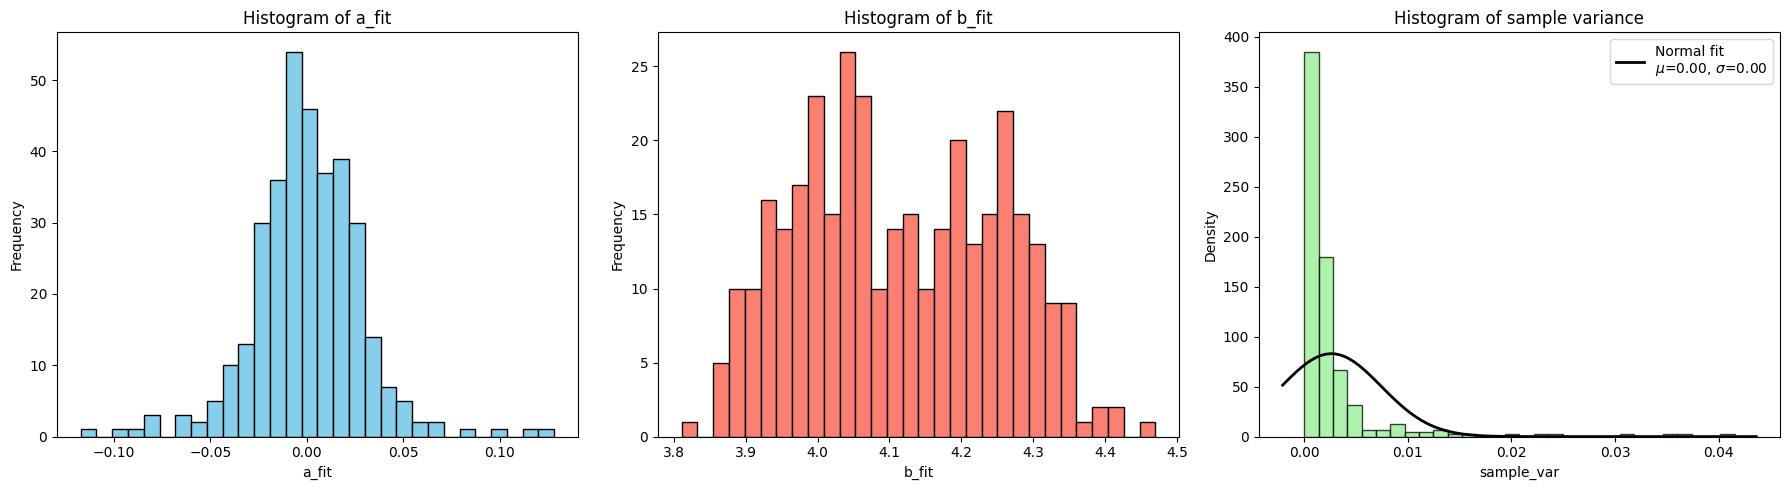

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Plot histograms for 'a_fit', 'b_fit', and 'sample_var' (sample variance)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# a_fit histogram
axs[0].hist(rolling_fit_df["a_fit"].dropna(), bins=30, color='skyblue', edgecolor='black')
axs[0].set_title('Histogram of a_fit')
axs[0].set_xlabel('a_fit')
axs[0].set_ylabel('Frequency')

# b_fit histogram
axs[1].hist(rolling_fit_df["b_fit"].dropna(), bins=30, color='salmon', edgecolor='black')
axs[1].set_title('Histogram of b_fit')
axs[1].set_xlabel('b_fit')
axs[1].set_ylabel('Frequency')

# sample_var histogram & fit
sample_var_data = rolling_fit_df["sample_var"].dropna()
axs[2].hist(sample_var_data, bins=30, color='lightgreen', edgecolor='black', alpha=0.75, density=True)
axs[2].set_title('Histogram of sample variance')
axs[2].set_xlabel('sample_var')
axs[2].set_ylabel('Density')
# Fit a normal distribution to the sample variance data
mu, std = norm.fit(sample_var_data)
xmin, xmax = axs[2].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
axs[2].plot(x, p, 'k', linewidth=2, label=f'Normal fit\n$\mu$={mu:.2f}, $\sigma$={std:.2f}')
axs[2].legend()

plt.tight_layout()
plt.show()

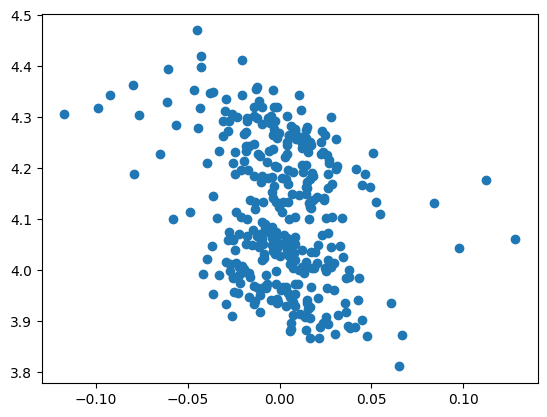

In [53]:
plt.scatter(rolling_fit_df['a_fit'], rolling_fit_df['b_fit'])